# Commodity Return Forecasting — EDA & Backtest


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname("__file__"), ".."))

from src.data import load_data
from src.config import TARGETS
from src.features import engineer_base_features, engineer_target_features
from src.backtest import walkforward, print_results
from src.analysis import (
    plot_target_distributions, check_stationarity, plot_missing_values,
    plot_feature_target_correlations, plot_rolling_correlations,
    plot_feature_correlation_matrix, plot_cumulative_pnl,
    print_backtest_stats, plot_feature_importance,
)
from src.models import make_elasticnet


In [2]:
df, feature_cols = load_data()
FEATURE_COLS = feature_cols  # alias for the analysis functions


Period:       2000-01-03 -> 2025-02-06
Observations: 6,549
Features:     60
Missing:      43.0%


## 1. EDA


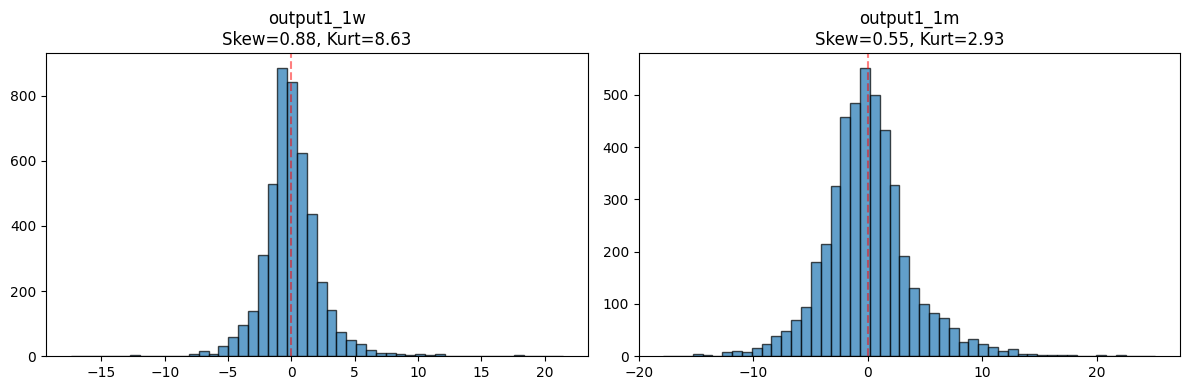

output1_1w: ADF stat=-16.632, p=1.66e-29 -> Stationary
output1_1m: ADF stat=-12.016, p=3.10e-22 -> Stationary


In [3]:
plot_target_distributions(df, TARGETS)
check_stationarity(df, TARGETS)


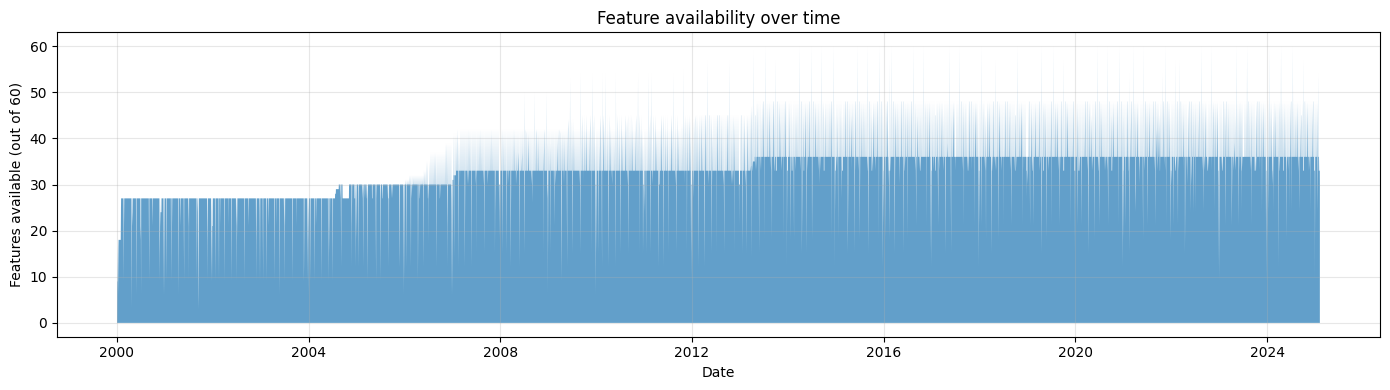

Features with >50% missing: 27
Features with >20% missing: 30
Features with 0% missing:   0


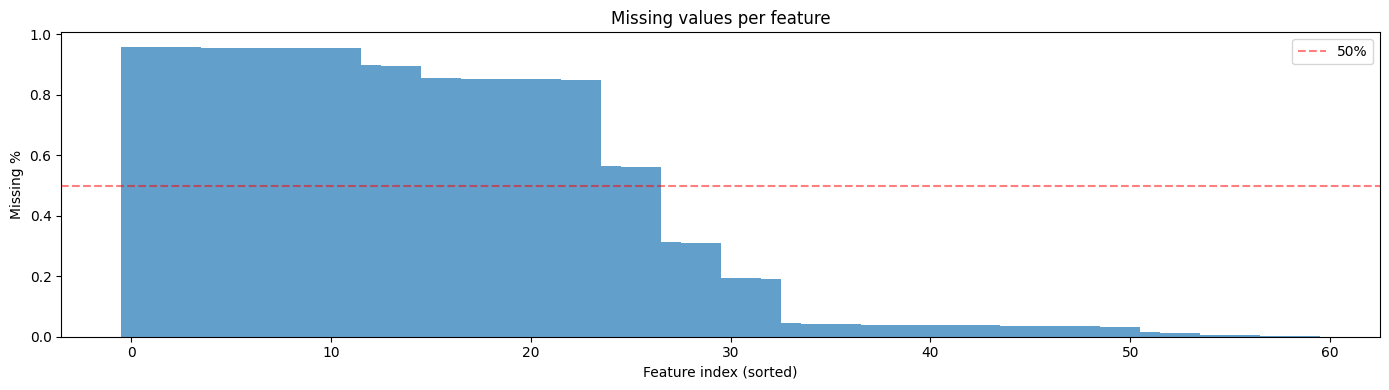

In [4]:
plot_missing_values(df, FEATURE_COLS)



output1_1w -- top 10 correlated features:
feature8_5_period      0.0563
feature19_21_period    0.0607
feature8_21_period     0.0661
feature1_21_period     0.0933
feature6_1_period      0.0946
feature4_21_period     0.1169
feature4_5_period      0.1247
feature19_1_period     0.1403
feature1_1_period      0.1541
feature1_5_period      0.2753

output1_1w -- bottom 10:
feature5_21_period    -0.0813
feature20_1_period    -0.0488
feature11_21_period   -0.0487
feature12_21_period   -0.0453
feature17_1_period    -0.0433
feature13_21_period   -0.0428
feature11_1_period    -0.0411
feature14_5_period    -0.0405
feature11_5_period    -0.0372
feature10_5_period    -0.0327

output1_1m -- top 10 correlated features:
feature8_21_period     0.0854
feature1_1_period      0.1143
feature6_5_period      0.1186
feature19_1_period     0.1263
feature6_21_period     0.1370
feature19_5_period     0.1387
feature6_1_period      0.1416
feature19_21_period    0.1783
feature1_5_period      0.2546
feature1_21_period

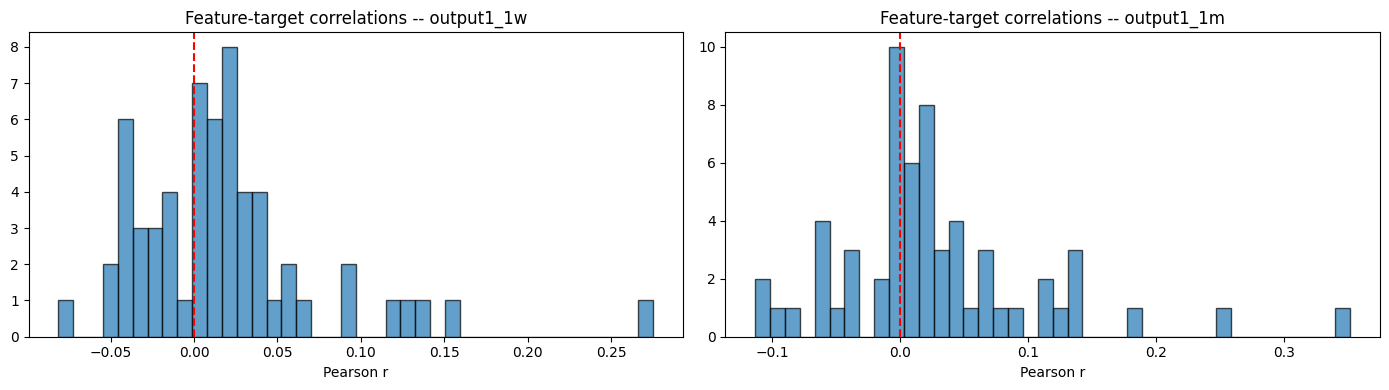

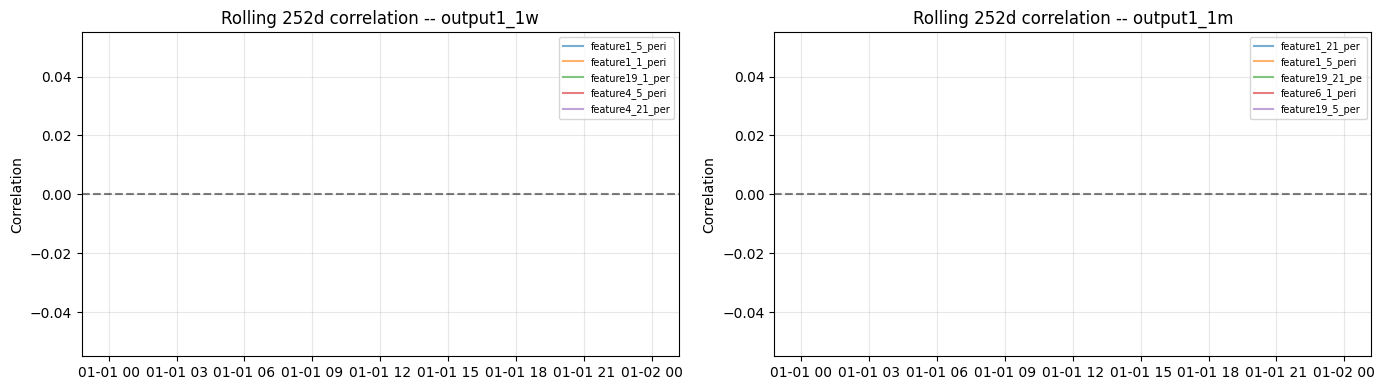

Feature pairs with |corr| > 0.9: 2


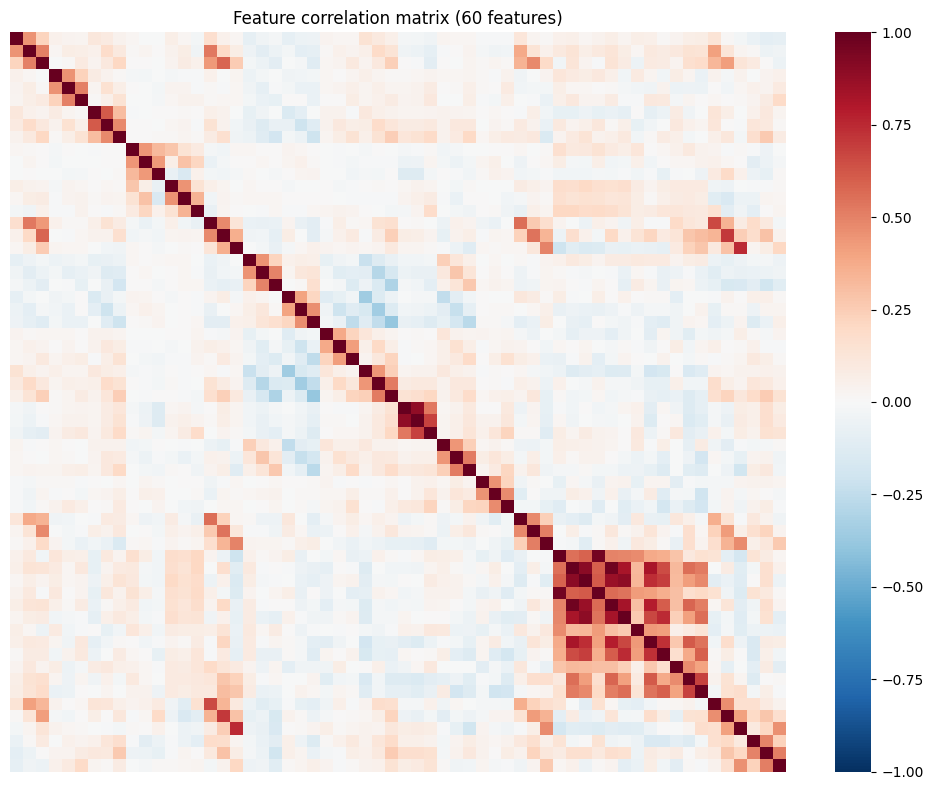

In [5]:
plot_feature_target_correlations(df, TARGETS, FEATURE_COLS)
plot_rolling_correlations(df, TARGETS, FEATURE_COLS)
plot_feature_correlation_matrix(df, FEATURE_COLS)


## 2. Feature Engineering


In [6]:
# base features are target-independent (z-scores, ranks, vol)
# safe to compute on full dataset
df_base, base_cols = engineer_base_features(df, feature_cols)
base_feature_set = feature_cols + base_cols
print(f"Total base features: {len(base_feature_set)}")


Base features: 240 new columns
Total base features: 300


## 3. Walk-Forward Backtest


In [7]:
# elasticnet baseline on raw features
for target in TARGETS:
    results, oos, _ = walkforward(
        df, feature_cols, target,
        model_factory=make_elasticnet,
        use_early_stopping=False,
    )
    print_results(results, target, "ElasticNet")



ElasticNet -- output1_1w (horizon=5d)
 fold     ic  ic_95_lo  ic_95_hi  hit_rate  sharpe   max_dd
    1 0.4465    0.2333    0.6064    0.5621  1.6067 -49.0957
    2 0.3920    0.2386    0.5230    0.5752  2.3457 -18.6681
    3 0.4731    0.3266    0.6055    0.6601  2.5881 -30.2366
    4 0.2993    0.0981    0.4942    0.6601  2.5145 -51.2128
    5 0.3981    0.2044    0.5650    0.6732  2.8112 -33.6418

Mean: IC=0.402 +/- 0.067, Hit=62.6%, Sharpe=2.37, MaxDD=-36.5710%
IC t-stat=13.51, p=0.0002 (significant at 5%)

ElasticNet -- output1_1m (horizon=21d)
 fold     ic  ic_95_lo  ic_95_hi  hit_rate  sharpe   max_dd
    1 0.4844    0.1509    0.7305    0.5946  1.5126 -45.8970
    2 0.4294    0.1277    0.6636    0.6486  1.5410 -65.0381
    3 0.1295   -0.1275    0.3997    0.5946  0.5503 -75.4014
    4 0.1539   -0.3350    0.6267    0.5405  0.7426 -92.5531
    5 0.0089   -0.4083    0.5756    0.5946  0.5571 -80.0928

Mean: IC=0.241 +/- 0.205, Hit=59.5%, Sharpe=0.98, MaxDD=-71.7965%
IC t-stat=2.63, p=0.0

In [ ]:
# xgboost on raw features
for target in TARGETS:
    results, oos, _ = walkforward(df, feature_cols, target)
    print_results(results, target, "XGBoost (raw)")


Target-specific features (output1_1w, h=5): 180 new columns

XGBoost (engineered) -- output1_1w (horizon=5d)
 fold     ic  ic_95_lo  ic_95_hi  hit_rate  sharpe   max_dd
    1 0.4245    0.3158    0.5276    0.6013  1.9949 -20.6769
    2 0.3687    0.2155    0.5167    0.6340  2.0455 -31.9196
    3 0.5521    0.3781    0.6950    0.6667  2.7384 -22.8660
    4 0.5093    0.3943    0.6142    0.6993  3.0943 -16.1182
    5 0.4675    0.3064    0.6368    0.6863  3.1878  -8.8604

Mean: IC=0.464 +/- 0.072, Hit=65.8%, Sharpe=2.61, MaxDD=-20.0882
IC t-stat=14.51, p=0.0001 (significant at 5%)

output1_1w (horizon=5d):
  IC (non-overlap):       0.402
  Hit rate:               65.8%
  Sharpe (ann.):          2.42
  Max drawdown (units):   -32.0402
  Calmar ratio:           0.94
  Win/Loss ratio:         2.10
  Avg daily turnover:     35.15%
  N obs (non-overlap):    765


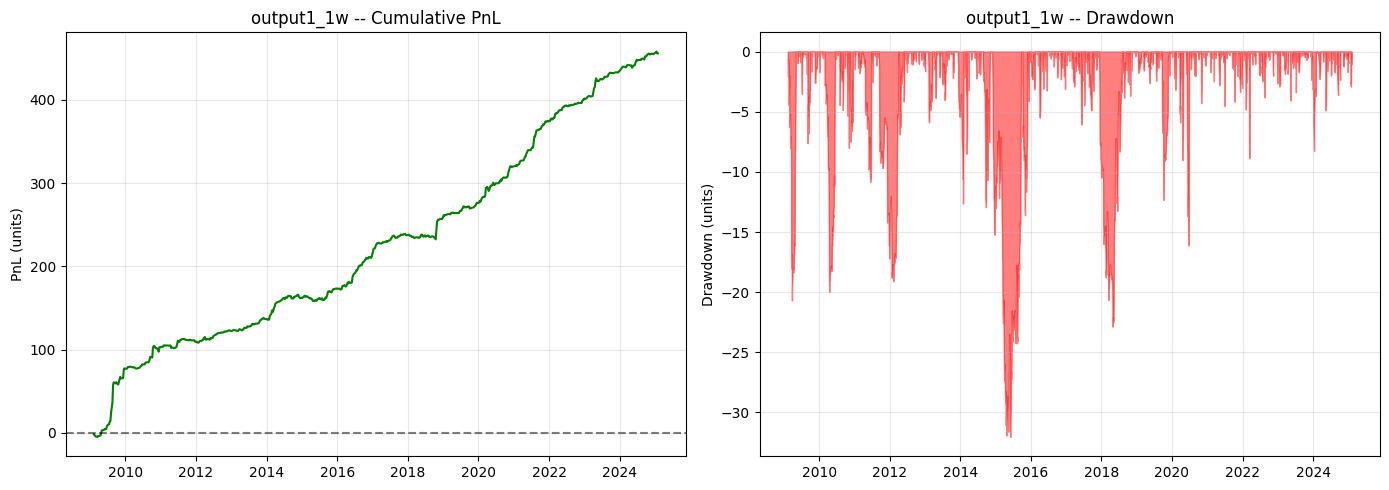

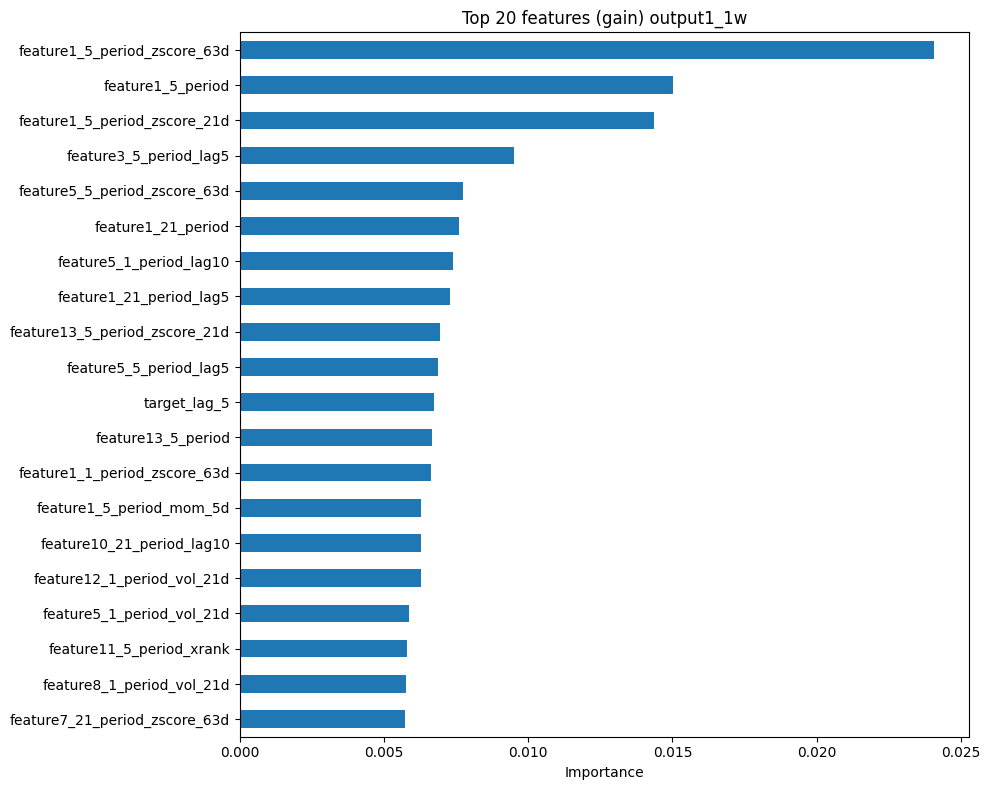

Target-specific features (output1_1m, h=21): 180 new columns

XGBoost (engineered) -- output1_1m (horizon=21d)
 fold     ic  ic_95_lo  ic_95_hi  hit_rate  sharpe    max_dd
    1 0.0545   -0.2295    0.3222    0.4595 -0.0783 -263.5743
    2 0.5092    0.2269    0.7299    0.6216  1.6813 -129.0399
    3 0.2298   -0.0075    0.4567    0.5946  0.6719  -96.1199
    4 0.4584    0.1462    0.7142    0.6757  1.3683  -49.4732
    5 0.4311   -0.0820    0.8125    0.5676  1.2376  -73.9916

Mean: IC=0.337 +/- 0.190, Hit=58.4%, Sharpe=0.98, MaxDD=-122.4398
IC t-stat=3.96, p=0.0167 (significant at 5%)

output1_1m (horizon=21d):
  IC (non-overlap):       0.285
  Hit rate:               55.2%
  Sharpe (ann.):          0.89
  Max drawdown (units):   -269.7819
  Calmar ratio:           0.03
  Win/Loss ratio:         1.71
  Avg daily turnover:     19.74%
  N obs (non-overlap):    181


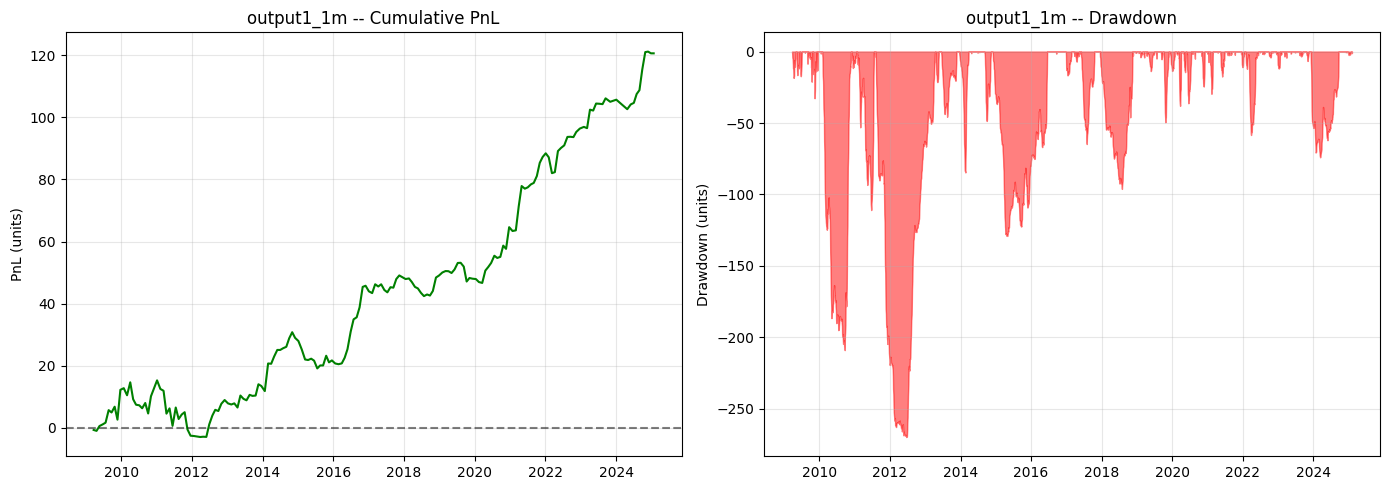

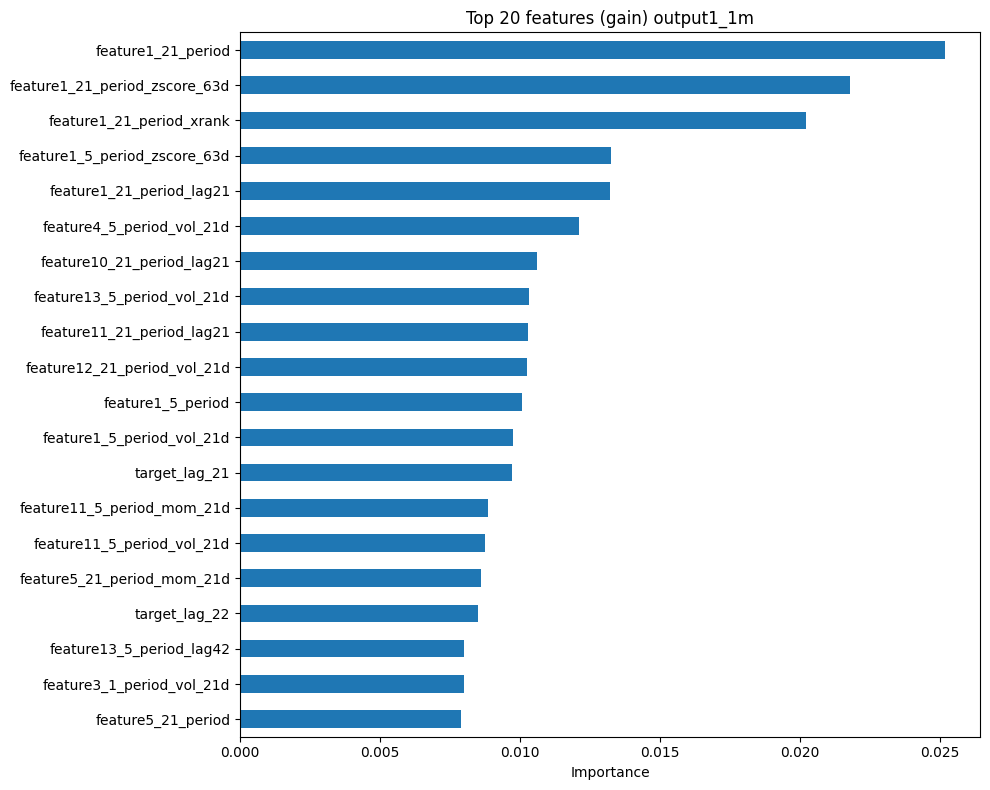

In [ ]:
# xgboost on engineered features
# target-specific features (lags, momentum) depend on the horizon
for target in TARGETS:
    df_full, tgt_cols = engineer_target_features(df_base, feature_cols, target)
    full_features = base_feature_set + tgt_cols
    
    results, oos, model = walkforward(df_full, full_features, target)
    print_results(results, target, "XGBoost (engineered)")
    
    print_backtest_stats(oos, target)
    plot_cumulative_pnl(oos, target)
    plot_feature_importance(model, n_top=20, title=target)
